In [ ]:
!pip install -q ultralytics opencv-python matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 3.2 MB/s eta 0:00:00


In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
uploaded = files.upload()

filename = list(uploaded.keys())[0]

image = cv2.imread(filename)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

Saving ChatGPT Image Sep 9, 2026, 10_18_44 PM.png to ChatGPT Image Sep 9, 2026, 10_18_44 PM.png


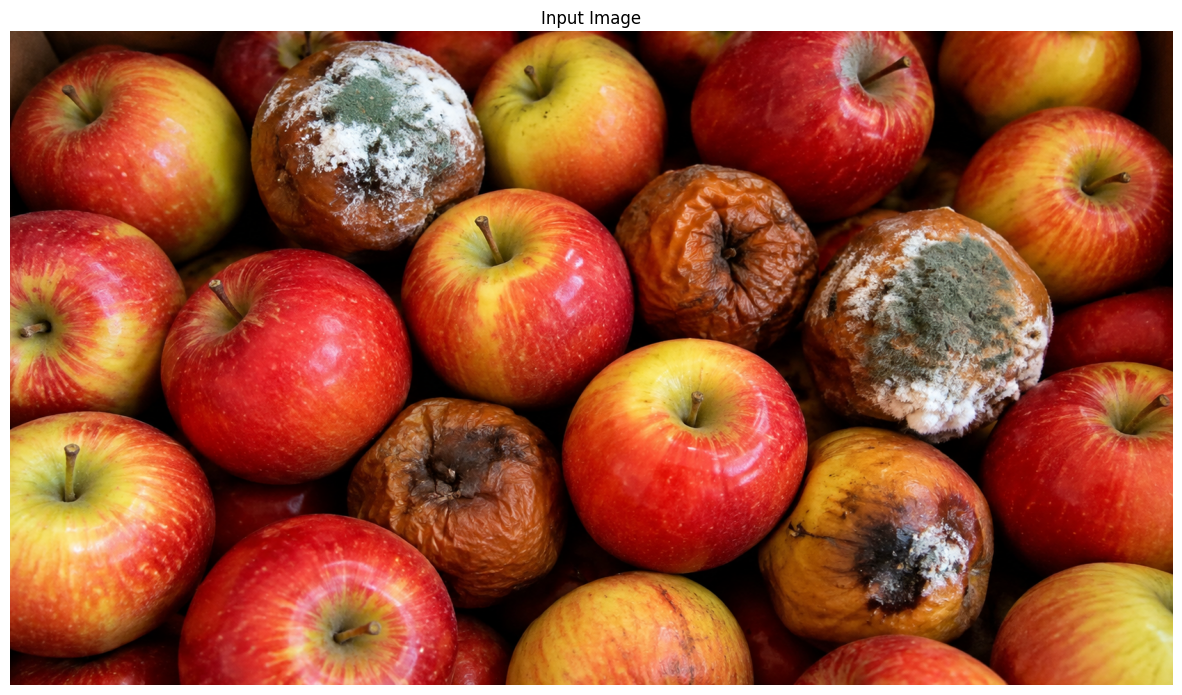

In [ ]:
plt.figure(figsize=(15, 9))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Input Image")
plt.show()

In [ ]:
from ultralytics import YOLO

# Segmentation model
model = YOLO("yolo11n-seg.pt")

results = model(
    image,
    conf=0.25
)

result = results[0]

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.

0: 384x640 12 apples, 472.5ms
Speed: 27.4ms preprocess, 472.5ms inference, 65.7ms postprocess per image at shape (1, 3, 384, 640)


In [ ]:
good_fruit_masks = []

if result.masks is not None:

    masks = result.masks.data.cpu().numpy()
    boxes = result.boxes

    for i, box in enumerate(boxes):

        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        confidence = float(box.conf[0])

        if class_name != "apple":
            continue

        # Get segmentation mask
        mask = masks[i]

        # Resize mask to original image size
        mask = cv2.resize(
            mask,
            (image.shape[1], image.shape[0])
        )

        mask = (mask > 0.5).astype(np.uint8) * 255

        good_fruit_masks.append(mask)

print("Apple masks found:", len(good_fruit_masks))

Apple masks found: 12


In [ ]:
def calculate_damage(image_rgb, mask):

    hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)

    # Only pixels belonging to the apple
    apple_pixels = mask > 0

    if np.sum(apple_pixels) == 0:
        return 1.0

    H = hsv[:, :, 0]
    S = hsv[:, :, 1]
    V = hsv[:, :, 2]

    # Dark regions
    dark = (
        (V < 70) &
        apple_pixels
    )

    # Brown/damaged regions
    brown = (
        (H >= 5) &
        (H <= 30) &
        (S > 70) &
        (V < 180) &
        apple_pixels
    )

    # Possible mold regions
    white_mold = (
        (S < 80) &
        (V > 170) &
        apple_pixels
    )

    total = np.sum(apple_pixels)

    dark_ratio = np.sum(dark) / total
    brown_ratio = np.sum(brown) / total
    mold_ratio = np.sum(white_mold) / total

    # Overall damage score
    damage_score = (
        0.4 * dark_ratio +
        0.4 * brown_ratio +
        0.2 * mold_ratio
    )

    return damage_score

In [ ]:
THRESHOLD = 0.18

good_masks = []

for mask in good_fruit_masks:

    damage = calculate_damage(
        image_rgb,
        mask
    )

    print("Damage score:", round(damage, 3))

    if damage < THRESHOLD:

        # Keep this apple
        good_masks.append(mask)

print("Good apples:", len(good_masks))

Damage score: 0.027
Damage score: 0.113
Damage score: 0.078
Damage score: 0.057
Damage score: 0.042
Damage score: 0.17
Damage score: 0.073
Damage score: 0.187
Damage score: 0.162
Damage score: 0.095
Damage score: 0.067
Damage score: 0.303
Good apples: 10


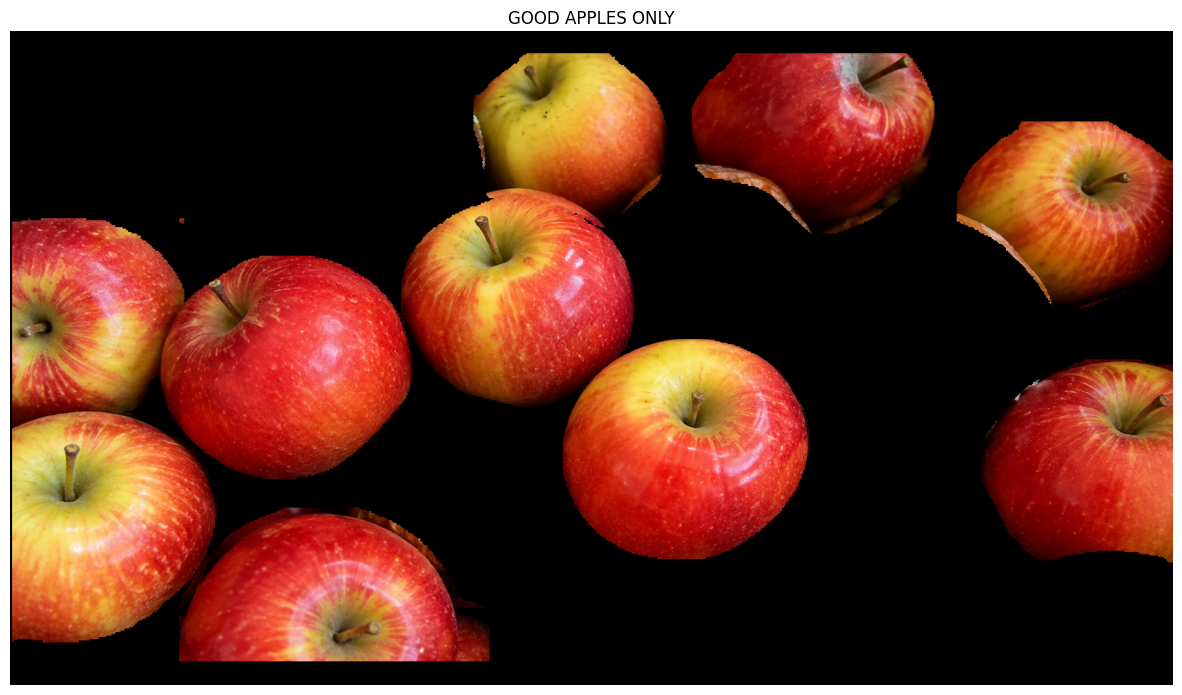

In [ ]:
# Create completely black background
output = np.zeros_like(image_rgb)

# Combine masks of all good apples
combined_mask = np.zeros(
    image_rgb.shape[:2],
    dtype=np.uint8
)

for mask in good_masks:
    combined_mask = cv2.bitwise_or(
        combined_mask,
        mask
    )

# Put only good apple pixels into output
output[combined_mask > 0] = image_rgb[combined_mask > 0]

# Display
plt.figure(figsize=(15, 9))
plt.imshow(output)
plt.axis("off")
plt.title("GOOD APPLES ONLY")
plt.show()

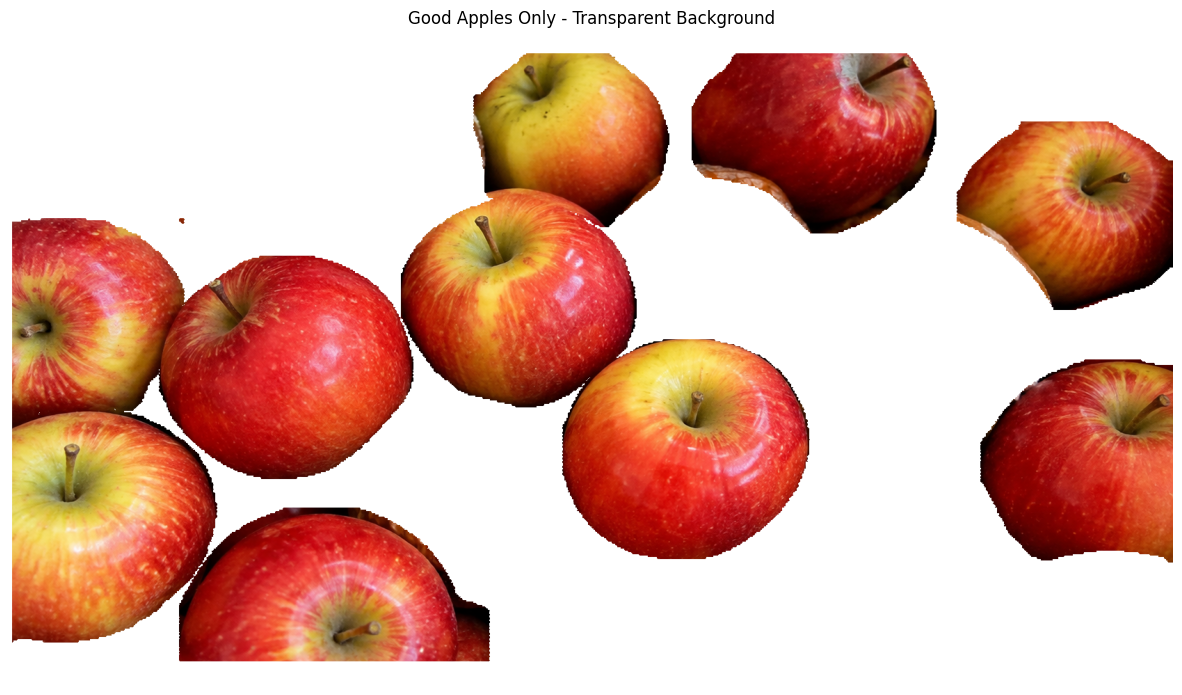

In [ ]:
# Create RGBA image
output_rgba = np.zeros(
    (image_rgb.shape[0],
     image_rgb.shape[1],
     4),
    dtype=np.uint8
)

# RGB values
output_rgba[:, :, :3] = image_rgb

# Transparency:
# Good apple = 255
# Everything else = 0
output_rgba[:, :, 3] = combined_mask

plt.figure(figsize=(15, 9))
plt.imshow(output_rgba)
plt.axis("off")
plt.title("Good Apples Only - Transparent Background")
plt.show()

In [ ]:
output_bgra = cv2.cvtColor(
    output_rgba,
    cv2.COLOR_RGBA2BGRA
)

cv2.imwrite(
    "good_apples_only.png",
    output_bgra
)

print("Saved: good_apples_only.png")

Saved: good_apples_only.png
